In [26]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import pandas as pd

In [27]:
# 1. 데이터 준비
num_classes = 10
input_shape = (32, 32, 3)

**1. Training Set X,Y 설정**

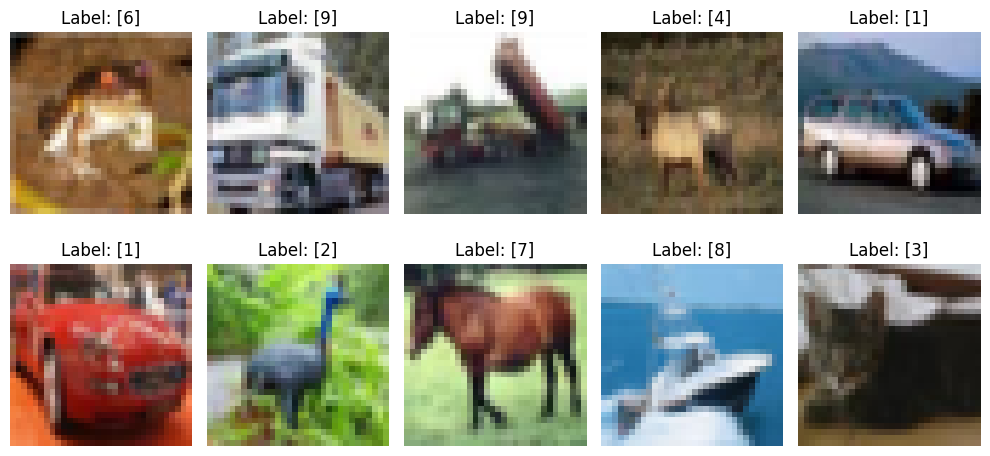

In [28]:
# MNIST 데이터셋 로드
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


In [29]:
    # 이미지 픽셀 값을 0 ~ 1 사이로 정규화
    x_train = x_train.astype("float32") / 255
    x_test = x_test.astype("float32") / 255


In [30]:
    # 색상채널이 있어서 reshape 불필요


    print("x_train shape:", x_train.shape)
    print(x_train.shape[0], "train samples")
    print(x_test.shape[0], "test samples")


x_train shape: (50000, 32, 32, 3)
50000 train samples
10000 test samples


**모델 구성**

In [31]:
    # 2. CNN 모델 구성
# 3. 모델 구성 (Conv-Pool 블록을 더 추가하는 것이 포인트)

model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu'), # Input 채널 3 확인
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ]
)

model.summary()

# 3. 모델 학습 설정 및 학습 진행
# 128개씩 끊어서 학습하고 검증 한다. 전체 데이터를 5번 반복한다.
batch_size = 128
epochs = 5
#model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])



Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)                   │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 4, 4, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 64)                  │          65,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

**모델 학습**

In [32]:
y_train

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], shape=(50000, 1), dtype=uint8)

In [33]:
    print("\n모델 학습을 시작합니다...")
    model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)


모델 학습을 시작합니다...
Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 19s 45ms/step - accuracy: 0.3866 - loss: 1.6666 - val_accuracy: 0.4676 - val_loss: 1.4732
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.5158 - loss: 1.3483 - val_accuracy: 0.5578 - val_loss: 1.2368
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.5726 - loss: 1.1993 - val_accuracy: 0.5962 - val_loss: 1.1476
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.6148 - loss: 1.0930 - val_accuracy: 0.6236 - val_loss: 1.0763
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.6482 - loss: 1.0063 - val_accuracy: 0.6490 - val_loss: 0.9891


In [34]:
    # 4. 모델 평가
    score = model.evaluate(x_test, y_test, verbose=0)
    print("\n--- 학습 결과 ---")
    print("Test loss:", score[0])
    print("Test accuracy:", score[1])


--- 학습 결과 ---
Test loss: 1.0161590576171875
Test accuracy: 0.6467999815940857


In [35]:
sample=x_test[0]
sample=np.expand_dims(sample,axis=0)
model.predict(sample)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step


array([[6.5750224e-03, 5.8049951e-05, 1.9228598e-02, 7.3735011e-01,
        2.4385541e-03, 2.1631847e-01, 4.0063593e-03, 1.9642033e-03,
        1.1369022e-02, 6.9162576e-04]], dtype=float32)